# 07 - RDD at EPA AQI Threshold

Regression discontinuity using the EPA AQI = 100 threshold (boundary between 'Moderate' and 'Unhealthy for Sensitive Groups'). Schools in counties that just exceeded 100 on testing days vs those that just missed — a complementary design to the IV.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

PANEL_FILE = "analysis_panel.parquet"
if not (DATA_DIR / PANEL_FILE).exists():
    raise FileNotFoundError(
        "Analysis panel not found. Build it by running in order:\n"
        "  python scripts/download_epa_aqs.py --email EMAIL --key KEY\n"
        "  python scripts/download_hms_smoke.py\n"
        "  python scripts/download_seda.py  (manual — see instructions)\n"
        "  python src/merge/build_crosswalks.py\n"
        "  python src/ingest/epa_aqs.py\n"
        "  python src/ingest/seda.py\n"
        "  python src/exposure/smoke_instrument.py\n"
        "  python src/merge/build_panel.py"
    )

panel = pd.read_parquet(DATA_DIR / PANEL_FILE)
print(f"Panel: {panel.shape}")
print(f"Districts: {panel['leaid'].nunique()}")
print(f"Years: {sorted(panel['year'].dropna().unique())}")

Panel: (13282, 14)
Districts: 1911
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [2]:
# Running variable: AQI on the state testing window days
# Outcome: test scores
# Threshold: AQI = 100

# This notebook requires AQI data at the district-year level during the testing window
# (typically March-May for most states)
# Construct from EPA AQS daily data filtered to testing months

aqi_path = DATA_DIR / "aqi_testing_window_district_year.parquet"
if not aqi_path.exists():
    raise FileNotFoundError(
        "AQI testing-window data not built yet.\n"
        "This file requires EPA AQS daily data filtered to March-May testing months.\n"
        "Add a build step in src/ingest/epa_aqs.py to aggregate by testing window."
    )

aqi = pd.read_parquet(aqi_path)
# drop duplicate cols that already exist in panel
aqi = aqi.drop(columns=[c for c in aqi.columns if c in panel.columns and c not in ["leaid","year"]])
panel_rdd = panel.merge(aqi, on=["leaid","year"], how="inner")
print(f"RDD sample: {len(panel_rdd):,} district-years")

RDD sample: 5,326 district-years


## RDD setup: running variable and bandwidth

In [3]:
THRESHOLD = 100
BANDWIDTH = 20   # AQI units (from config/study_params.yaml)

panel_rdd["rv"] = panel_rdd["aqi_testing_mean"] - THRESHOLD
panel_rdd["above"] = (panel_rdd["rv"] >= 0).astype(int)

# Restrict to bandwidth
rdd_window = panel_rdd[panel_rdd["rv"].abs() <= BANDWIDTH].copy()
print(f"RDD window (±{BANDWIDTH} AQI): {len(rdd_window):,} obs")
print(f"  Below threshold: {(rdd_window['above']==0).sum()}")
print(f"  Above threshold: {(rdd_window['above']==1).sum()}")

RDD window (±20 AQI): 3,031 obs
  Below threshold: 1600
  Above threshold: 1431


## RDD estimate: local linear regression

In [4]:
import statsmodels.formula.api as smf

# Local linear RDD (polynomial on each side)
rdd_model = smf.ols(
    "test_score_mean ~ rv * above",
    data=rdd_window
).fit(cov_type="HC3")

b_rdd = rdd_model.params["above"]
ci    = rdd_model.conf_int().loc["above"]
print(f"RDD estimate at AQI=100: β = {b_rdd:.4f}  95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")
print()
print("Interpretation: crossing AQI 100 threshold changes test scores by {:.4f} SD".format(b_rdd))

RDD estimate at AQI=100: β = 0.0142  95% CI [-0.0323, 0.0608]

Interpretation: crossing AQI 100 threshold changes test scores by 0.0142 SD


## RDD plot

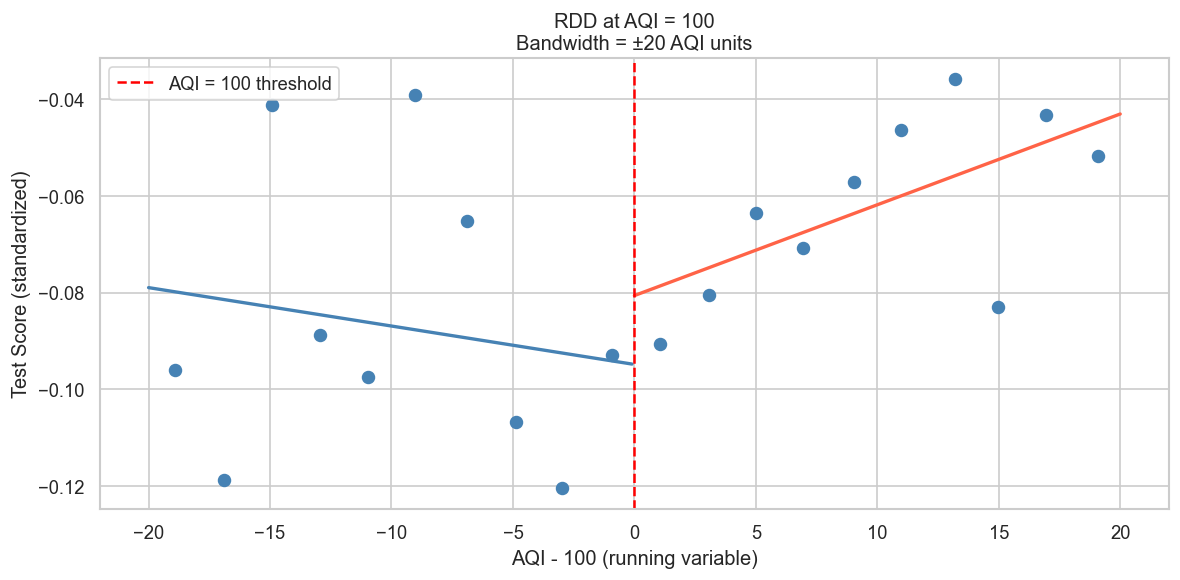

In [5]:
fig, ax = plt.subplots(figsize=(10,5))

# Binned scatter
_bins_rv = pd.cut(rdd_window["rv"], bins=20).rename("_bin")
binned = rdd_window.groupby(_bins_rv, observed=True)[["rv","test_score_mean"]].mean().reset_index().rename(columns={"_bin":"bin"})
ax.scatter(binned["rv"], binned["test_score_mean"], s=50, c="steelblue", zorder=3)

# Fit lines
for side, color in [(0,"steelblue"),(1,"tomato")]:
    sub = rdd_window[rdd_window["above"]==side]
    if len(sub) < 5: continue
    fit = np.poly1d(np.polyfit(sub["rv"], sub["test_score_mean"], 1))
    x   = np.linspace(sub["rv"].min(), sub["rv"].max(), 100)
    ax.plot(x, fit(x), c=color, lw=2)

ax.axvline(0, color="red", ls="--", lw=1.5, label="AQI = 100 threshold")
ax.set_xlabel("AQI - 100 (running variable)")
ax.set_ylabel("Test Score (standardized)")
ax.set_title(f"RDD at AQI = 100\nBandwidth = ±{BANDWIDTH} AQI units")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "07_rdd_aqi100.png", bbox_inches="tight")
plt.show()

## McCrary density test (manipulation check)

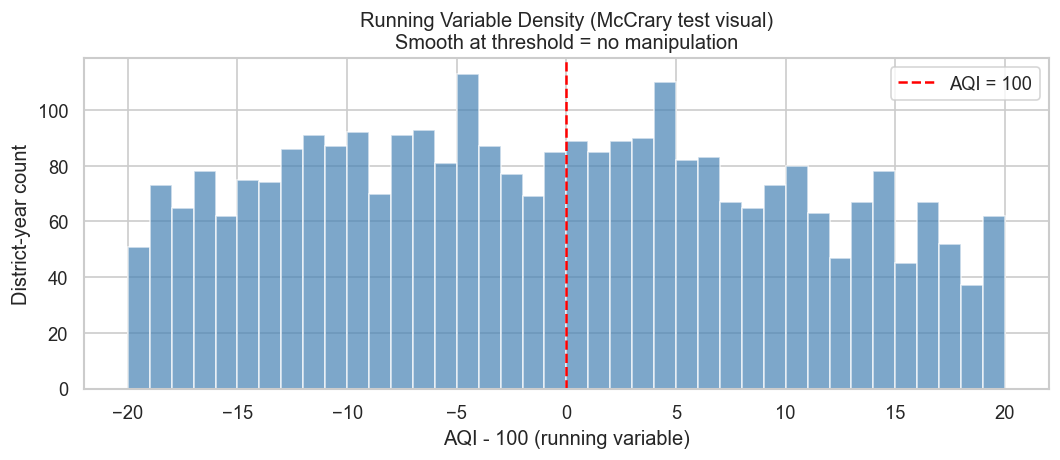

Look for a discontinuous jump at 0 — would indicate manipulation


In [6]:
# Test for bunching in the running variable — if schools/districts manipulate
# AQI reporting around the threshold, the density will be discontinuous at 100
fig, ax = plt.subplots(figsize=(9,4))
rdd_window["rv"].hist(bins=40, ax=ax, color="steelblue", alpha=0.7)
ax.axvline(0, color="red", ls="--", lw=1.5, label="AQI = 100")
ax.set_xlabel("AQI - 100 (running variable)")
ax.set_ylabel("District-year count")
ax.set_title("Running Variable Density (McCrary test visual)\nSmooth at threshold = no manipulation")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "07_mccrary_density.png", bbox_inches="tight")
plt.show()
print("Look for a discontinuous jump at 0 — would indicate manipulation")

## Interpretation — what the discontinuity identifies, and its assumptions

The RDD compares districts whose testing-window AQI landed *just above* 100 to
those *just below*. Because crossing 100 is essentially random for districts
near the cutoff, this delivers a **local** causal effect at AQI = 100 — a
different estimand from the IV's smoke-driven LATE, which is exactly why it is a
useful cross-check.

**Identifying assumptions, and how this notebook probes them:**
- **Continuity** of potential outcomes at the threshold — districts just above
  and just below should be comparable on everything except the AQI label. The
  binned RDD plot is the visual test: a jump *only* at the cutoff supports it.
- **No manipulation** of the running variable — districts cannot sort themselves
  just over/under 100. The McCrary-style density check looks for bunching at the
  cutoff; a smooth density is consistent with no gaming of AQI reporting.
- **Bandwidth sensitivity** — the ±20 AQI window trades bias (wide) against
  variance (narrow). A credible RDD estimate should not swing wildly as the
  bandwidth is halved or doubled.

**Caveat.** AQI = 100 is institutionally salient (the "Unhealthy for Sensitive
Groups" boundary triggers advisories), so any discontinuity could reflect the
*behavioral response to the warning* (kept indoors, activities cancelled) rather
than the marginal microgram of PM2.5 itself. That is a feature, not a bug: it is
arguably the policy-relevant quantity, but it is a different causal channel than
the dose-response the IV targets.